# **>>>ML PROJECT<<<**

# **1. Data Preparation**

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder,OrdinalEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

> # > Loading Dataset

In [64]:
df=pd.read_csv("/kaggle/input/datasets/divjotbedi/customer-dataset-with-education-age-gender/customer.csv")

In [65]:
df.sample(10)

,age,gender,purchased,review,education
462,65,Male,No,Excellent,UG
48,48,Male,No,Poor,UG
14,64,Male,Yes,Excellent,PG
276,58,Female,No,Poor,PG
332,19,Female,Yes,Good,UG
363,41,Female,No,Average,School
436,55,Male,No,Good,School
115,59,Female,Yes,Excellent,UG
344,56,Male,No,Good,UG
336,67,Female,Yes,Good,UG


In [66]:
df.shape

(500, 5)

In [67]:
df.isnull().sum()

age          0
gender       0
purchased    0
review       0
education    0
dtype: int64

> # > Encoding

In [68]:
Oe=OrdinalEncoder(categories=[['Poor','Average','Good','Excellent'],['School','UG','PG']])

In [69]:
df[['review','education']]=Oe.fit_transform(df[['review','education']])

In [70]:
df.head(10)

,age,gender,purchased,review,education
0,58,Male,Yes,2.0,1.0
1,32,Male,Yes,0.0,0.0
2,45,Male,Yes,0.0,1.0
3,32,Male,Yes,3.0,1.0
4,46,Female,Yes,1.0,0.0
5,45,Female,No,1.0,1.0
6,66,Female,Yes,0.0,2.0
7,24,Female,No,2.0,1.0
8,64,Female,Yes,3.0,1.0
9,53,Female,No,1.0,0.0


In [71]:
le = LabelEncoder()

In [72]:
df['gender']=le.fit_transform(df['gender'])
df['purchased']=le.fit_transform(df['purchased'])

In [73]:
df.head(10)

,age,gender,purchased,review,education
0,58,1,1,2.0,1.0
1,32,1,1,0.0,0.0
2,45,1,1,0.0,1.0
3,32,1,1,3.0,1.0
4,46,0,1,1.0,0.0
5,45,0,0,1.0,1.0
6,66,0,1,0.0,2.0
7,24,0,0,2.0,1.0
8,64,0,1,3.0,1.0
9,53,0,0,1.0,0.0


> # > Feature Scaling

In [74]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df1=pd.DataFrame(df_scaled,columns=df.columns)

In [75]:
df1.describe()

,age,gender,purchased,review,education
count,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02
mean,6.394885e-17,3.197442e-17,4.973799e-17,-4.618528e-17,8.881784e-17
std,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00
min,-1.779662e+00,-9.762812e-01,-9.841260e-01,-1.396388e+00,-1.182312e+00
25%,-7.642594e-01,-9.762812e-01,-9.841260e-01,-4.966536e-01,-1.182312e+00
50%,1.421563e-02,-9.762812e-01,-9.841260e-01,4.030812e-01,3.656634e-02
75%,8.773075e-01,1.024295e+00,1.016130e+00,1.302816e+00,1.255444e+00
max,1.740399e+00,1.024295e+00,1.016130e+00,1.302816e+00,1.255444e+00


# **2. CLUSTERING**

> # > K-Means Clustering

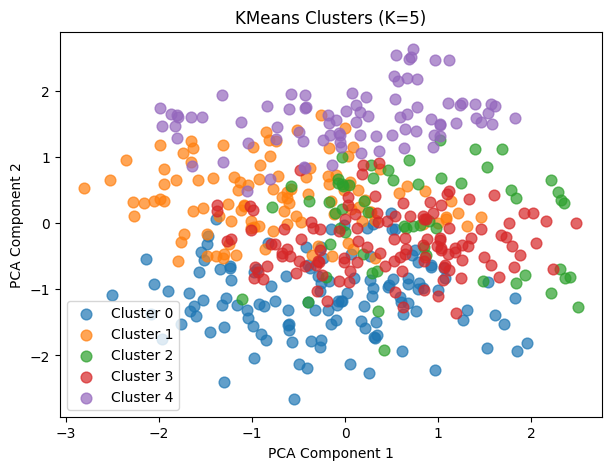

In [53]:
df1_jitter = df1 + np.random.normal(0, 0.2, df1.shape)
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df1_jitter)
km = KMeans(n_clusters=5, init='random', random_state=42, n_init=10)
df['kmeans_label'] = km.fit_predict(df1)

plt.figure(figsize=(7, 5))
for c in sorted(df['kmeans_label'].unique()):
    mask = df['kmeans_label'] == c
    plt.scatter(df_pca[mask, 0], df_pca[mask, 1], label=f'Cluster {c}', alpha=0.7, s=60)
plt.title('KMeans Clusters (K=5)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

> # > Agglomerative Clustering

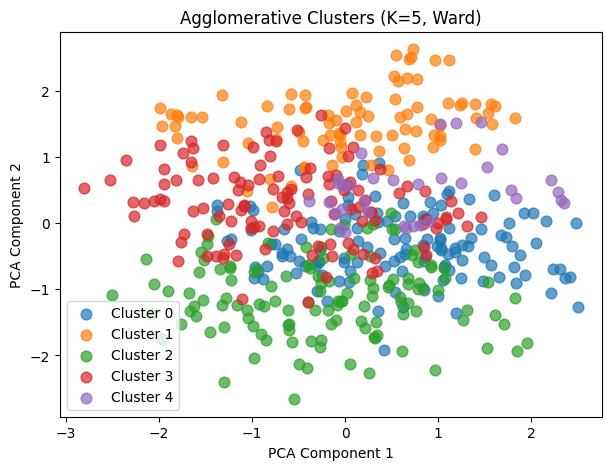

In [55]:
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['agg_label'] = agg.fit_predict(df1)

plt.figure(figsize=(7, 5))
for c in sorted(df['agg_label'].unique()):
    mask = df['agg_label'] == c
    plt.scatter(df_pca[mask, 0], df_pca[mask, 1], label=f'Cluster {c}', alpha=0.7, s=60)
plt.title('Agglomerative Clusters (K=5, Ward)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

> # > DBScan Clustering 

DBSCAN → 4 clusters, 0 noise points


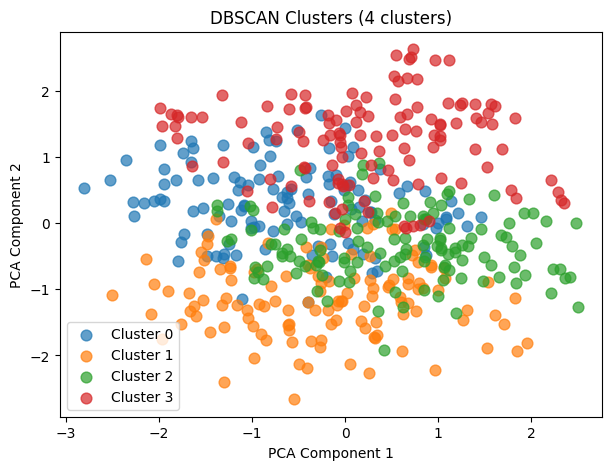

In [56]:
dbscan = DBSCAN(eps=1.22, min_samples=8)
df['dbscan_label'] = dbscan.fit_predict(df1)

n_clusters = df['dbscan_label'].nunique() - (1 if -1 in df['dbscan_label'].values else 0)
n_noise    = (df['dbscan_label'] == -1).sum()
print(f"DBSCAN → {n_clusters} clusters, {n_noise} noise points")

plt.figure(figsize=(7, 5))
for c in sorted(df['dbscan_label'].unique()):
    mask  = df['dbscan_label'] == c
    color = 'gray' if c == -1 else None
    label = 'Noise' if c == -1 else f'Cluster {c}'
    plt.scatter(df_pca[mask, 0], df_pca[mask, 1], label=label,
                alpha=0.7, s=60, color=color)
plt.title(f'DBSCAN Clusters ({n_clusters} clusters)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.show()

> # > Comparision

CLUSTERING COMPARISON
KMeans        Davies-Bouldin = 1.554
Agglomerative Davies-Bouldin = 1.572
DBSCAN        Davies-Bouldin = 1.678
(Lower Davies-Bouldin = Better)
  Best Algorithm : KMeans


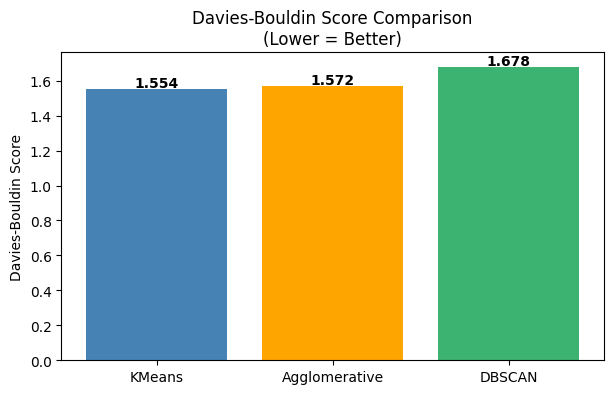

In [61]:
km_inertia  = km.inertia_
km_db       = davies_bouldin_score(df1, df['kmeans_label'])
agg_db      = davies_bouldin_score(df1, df['agg_label'])
mask        = df['dbscan_label'] != -1
dbscan_db   = davies_bouldin_score(df1[mask], df.loc[mask, 'dbscan_label'])

print("CLUSTERING COMPARISON")
print(f"KMeans        Davies-Bouldin = {km_db:.3f}")
print(f"Agglomerative Davies-Bouldin = {agg_db:.3f}")
print(f"DBSCAN        Davies-Bouldin = {dbscan_db:.3f}")
print("(Lower Davies-Bouldin = Better)")
best_cluster = min({'KMeans': km_db, 'Agglomerative': agg_db, 'DBSCAN': dbscan_db},
                    key=lambda x: {'KMeans': km_db, 'Agglomerative': agg_db, 'DBSCAN': dbscan_db}[x])
print(f"  Best Algorithm : {best_cluster}")

plt.figure(figsize=(7, 4))
methods = ['KMeans', 'Agglomerative', 'DBSCAN']
scores  = [km_db, agg_db, dbscan_db]
bars    = plt.bar(methods, scores, color=['steelblue', 'orange', 'mediumseagreen'])
for bar, v in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v:.3f}', ha='center', fontweight='bold')
plt.title('Davies-Bouldin Score Comparison\n(Lower = Better)')
plt.ylabel('Davies-Bouldin Score')
plt.show()

# **3. REGRESSION**

> # > Linear Regression

In [76]:
np.random.seed(42)
noise = np.random.normal(0, 8, len(df))

df['Spending_Score'] = (
    df['review']    * 15 +
    df['education']       * 12 +
    df['purchased'] * 18 +
    df['age'] * 0.4     +
    noise
).clip(0, 100).round(1)

print(df['Spending_Score'].describe())

count    500.00000
mean      61.27460
std       22.21484
min        0.00000
25%       45.10000
50%       62.40000
75%       77.40000
max      100.00000
Name: Spending_Score, dtype: float64


In [77]:
df.head()

,age,gender,purchased,review,education,Spending_Score
0,58,1,1,2.0,1.0,87.2
1,32,1,1,0.0,0.0,29.7
2,45,1,1,0.0,1.0,53.2
3,32,1,1,3.0,1.0,100.0
4,46,0,1,1.0,0.0,49.5


Linear Regression → R²=0.8863, RMSE=7.66


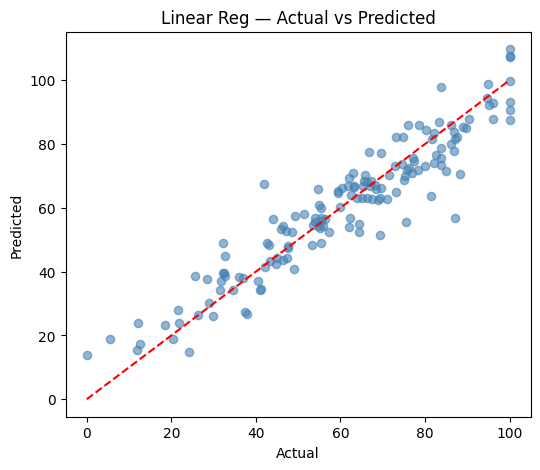

In [79]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Spending_Score']),
                                                    df['Spending_Score'], 
                                                    test_size=0.3,
                                                    random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f"Linear Regression → R²={r2_score(y_test, y_pred_lr):.4f}, RMSE={np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='steelblue', s=35)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Reg — Actual vs Predicted')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.show()

> # > Random Forest Regression

Random Forest → R²=0.8576, RMSE=8.57


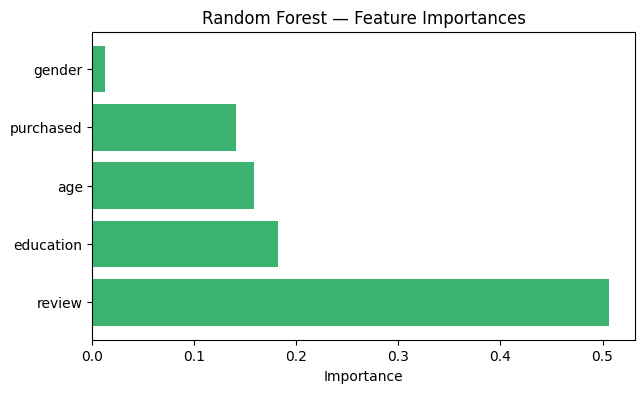

In [80]:
rf = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Random Forest → R²={r2_score(y_test, y_pred_rf):.4f}, RMSE={np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")

feat_names   = ['age','gender','purchased','review','education','kmeans_label']
importances  = rf.feature_importances_
idx          = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 4))
plt.barh([feat_names[i] for i in idx], importances[idx], color='mediumseagreen')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance'); plt.show()

# **4. Analysis**

In [81]:
print("       FINAL RESULTS SUMMARY")
print("\nClustering (Lower DB Score = Better):")
print(f"KMeans        = {km_db:.3f}")
print(f"Agglomerative = {agg_db:.3f}")
print(f"DBSCAN        = {dbscan_db:.3f}")

print("\nRegression (Higher R² = Better):")
print(f"Linear Reg    R²={r2_score(y_test, y_pred_lr):.4f}  RMSE={np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"Random Forest R²={r2_score(y_test, y_pred_rf):.4f}  RMSE={np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")

       FINAL RESULTS SUMMARY

Clustering (Lower DB Score = Better):
KMeans        = 1.554
Agglomerative = 1.572
DBSCAN        = 1.678

Regression (Higher R² = Better):
Linear Reg    R²=0.8863  RMSE=7.66
Random Forest R²=0.8576  RMSE=8.57
